# Task 3 – Baseline Model Training
**Agent:** Claude (claude-sonnet-4-6)  
**Date:** 2026-03-15  
**Dataset:** `data/processed/Claude_clean.csv`

Models trained:
- Logistic Regression (with standard scaling)
- Random Forest Classifier
- HistGradientBoosting Classifier

## Setup

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

FIGURES_DIR = "../../figures/Claude"
os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIG_COUNTER = [0]

def save_and_show(fig, name):
    """Save figure to figures/Claude/ with sequential numbering, then display."""
    FIG_COUNTER[0] += 1
    filename = f"{FIGURES_DIR}/fig_{FIG_COUNTER[0]:02d}_{name}.png"
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()
    plt.close(fig)

## 1. Load Dataset

In [3]:
df = pd.read_csv("../../data/processed/Claude_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 129,487 rows × 24 columns


## 2. Drop 'id' Column

In [4]:
df = df.drop(columns=["id"])
print(f"After dropping 'id': {df.shape[1]} columns remaining")

After dropping 'id': 23 columns remaining


## 3. Prepare Features

In [5]:
TARGET = "satisfaction"
y_raw = df[TARGET]
X_raw = df.drop(columns=[TARGET])

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
print(f"Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# One-hot encode categorical features
cat_cols = X_raw.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns encoded: {cat_cols}")
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"Feature matrix shape: {X.shape}")
display(X.head(3))

Target encoding: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}
Categorical columns encoded: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Feature matrix shape: (129487, 23)


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,4,5,5,25,18.0,True,False,True,False,True
1,25,235,3,2,3,3,1,3,1,1,...,1,4,1,1,6.0,True,True,False,False,False
2,26,1142,2,2,2,2,5,5,5,5,...,4,4,5,0,0.0,False,False,False,False,False


## 4. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

Train: 103,589 rows | Test: 25,898 rows
Train positive rate: 0.434 | Test positive rate: 0.435


## 5. Define Models

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200, max_depth=6, learning_rate=0.1, random_state=42
    ),
}
print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'Random Forest', 'HistGradientBoosting']


## 6. Train & Evaluate

In [8]:
results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {"accuracy": acc, "f1": f1, "roc_auc": auc,
                     "fpr": fpr, "tpr": tpr,
                     "y_pred": y_pred, "y_prob": y_prob}

    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC AUC  : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))


Training: Logistic Regression
  Accuracy : 0.8744
  F1 Score : 0.8529
  ROC AUC  : 0.9270

  Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     14645
              satisfied       0.87      0.84      0.85     11253

               accuracy                           0.87     25898
              macro avg       0.87      0.87      0.87     25898
           weighted avg       0.87      0.87      0.87     25898


Training: Random Forest
  Accuracy : 0.9596
  F1 Score : 0.9530
  ROC AUC  : 0.9933

  Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.97      0.96     14645
              satisfied       0.96      0.94      0.95     11253

               accuracy                           0.96     25898
              macro avg       0.96      0.96      0.96     25898
           weighted avg       0.96      0.96      0.

## 7. Visualisations
### Fig 8 – Metric comparison

Saved: ../../figures/Claude/fig_08_model_metric_comparison.png


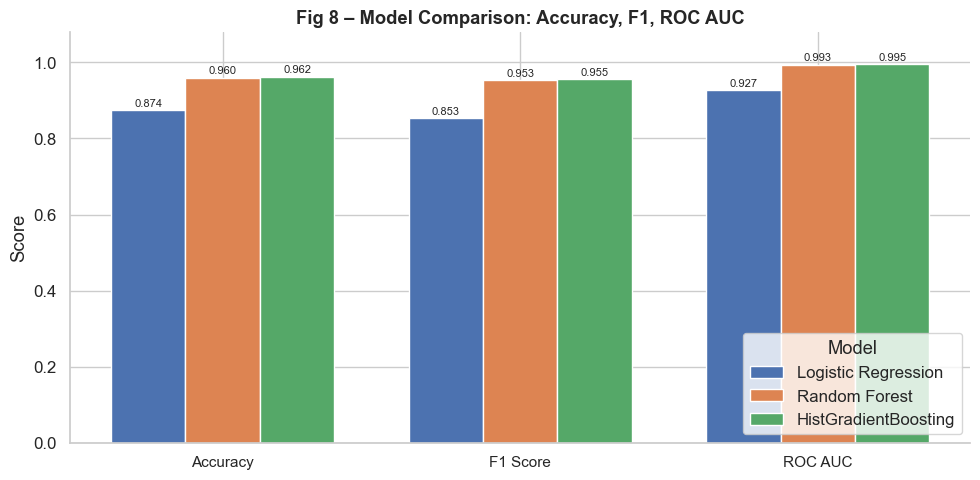

In [9]:
# Note: FIG_COUNTER starts at 0; task3 figs continue from fig_08 (task2 used 01-07)
FIG_COUNTER[0] = 7  # continue numbering from task2

metric_names  = ["accuracy", "f1", "roc_auc"]
metric_labels = ["Accuracy", "F1 Score", "ROC AUC"]
model_names   = list(results.keys())
x     = np.arange(len(metric_names))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Fig 8 – Model Comparison: Accuracy, F1, ROC AUC", fontweight="bold")
ax.legend(title="Model", loc="lower right")
sns.despine()
plt.tight_layout()
save_and_show(fig, "model_metric_comparison")

### Fig 9 – ROC curves

Saved: ../../figures/Claude/fig_09_roc_curves.png


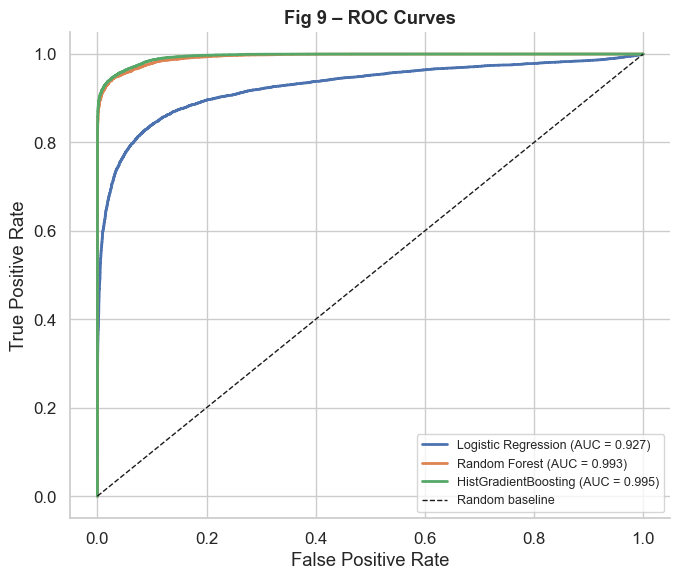

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(model_names, colors):
    fpr = results[name]["fpr"]
    tpr = results[name]["tpr"]
    auc = results[name]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Fig 9 – ROC Curves", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
sns.despine()
plt.tight_layout()
save_and_show(fig, "roc_curves")

### Fig 10 – Confusion matrices

Saved: ../../figures/Claude/fig_10_confusion_matrices.png


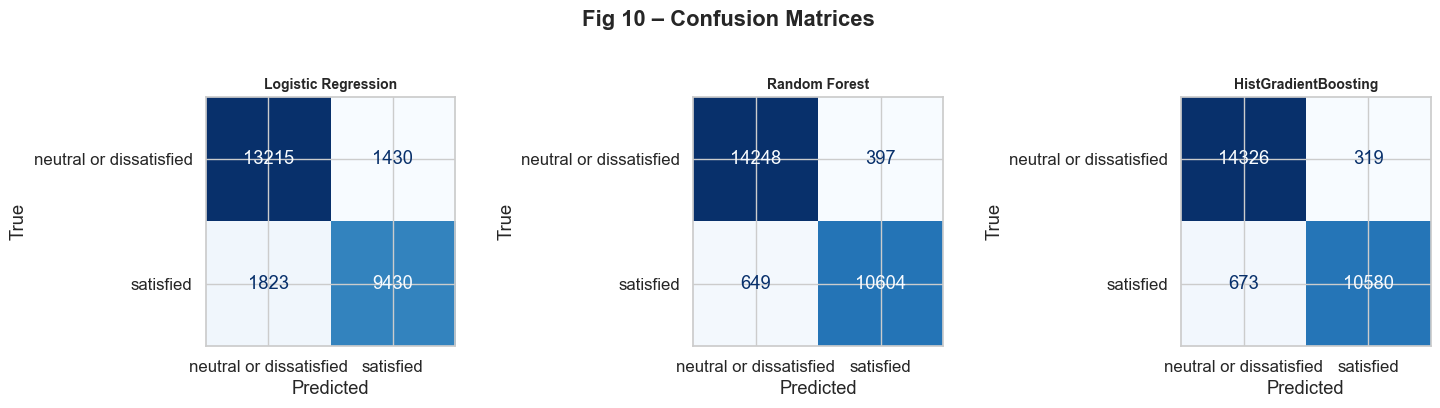

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.suptitle("Fig 10 – Confusion Matrices", fontweight="bold", y=1.02)
plt.tight_layout()
save_and_show(fig, "confusion_matrices")

### Fig 11 – Feature importances (Random Forest)

Saved: ../../figures/Claude/fig_11_feature_importance_rf.png


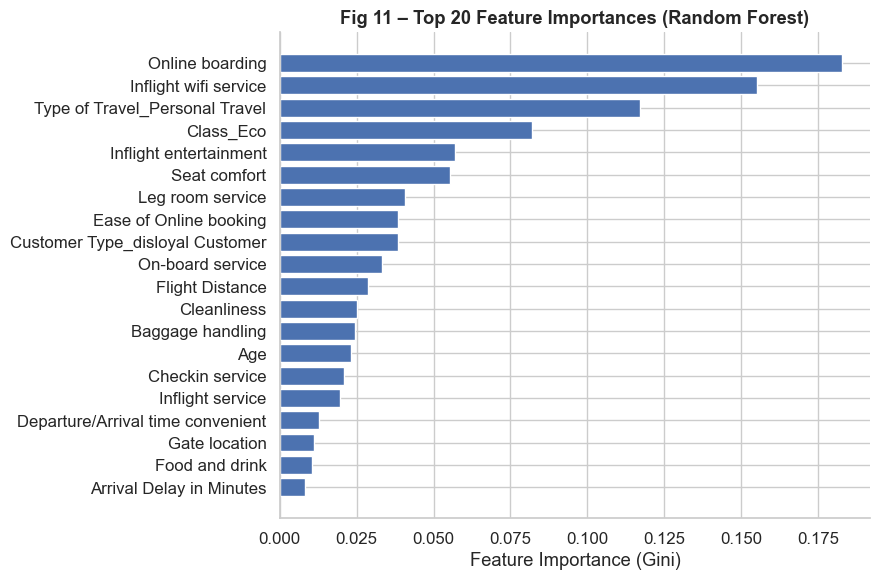

In [12]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Fig 11 – Top 20 Feature Importances (Random Forest)", fontweight="bold")
sns.despine()
plt.tight_layout()
save_and_show(fig, "feature_importance_rf")

## Results Summary

In [13]:
metric_names = ["accuracy", "f1", "roc_auc"]
summary = pd.DataFrame(
    {name: {m: round(results[name][m], 4) for m in metric_names}
     for name in model_names}
).T.rename(columns={"accuracy": "Accuracy", "f1": "F1 Score", "roc_auc": "ROC AUC"})
print("Final Results Summary:")
display(summary)

Final Results Summary:


,Accuracy,F1 Score,ROC AUC
Logistic Regression,0.8744,0.8529,0.9270
Random Forest,0.9596,0.9530,0.9933
HistGradientBoosting,0.9617,0.9552,0.9948
